## Georgia Gingles Analysis

In [22]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

import dill

In [23]:
demographics = ['white', 'black', 'latino', 'other']
candidates = ['harris', 'trump']

### Import Models

In [24]:
path = '../output/Georgia/models/ei_models.pkl'

In [25]:
with open(path, 'rb') as f:
    models = dill.load(f)

#### Get Sampled Shares Per Model 

In [26]:
def get_sample_shares(models):
    df = pd.DataFrame()

    for candidate in candidates:
        for demographic in demographics:
            ei = models[candidate][demographic]

            samples_matrix = ei.sim_trace["posterior"]["b_1"].stack(all_draws=["chain", "draw"]).values
            
            precinct_means = samples_matrix.mean(axis=1) 
            
            df[f'{demographic}_{candidate}_pct'] = precinct_means
    
    return df

In [27]:
sampled_shares = get_sample_shares(models)
sampled_shares

,white_harris_pct,black_harris_pct,latino_harris_pct,other_harris_pct,white_trump_pct,black_trump_pct,latino_trump_pct,other_trump_pct
0,0.025165,0.888562,0.641302,0.895915,0.974056,0.100413,0.322549,0.076855
1,0.024786,0.299678,0.665012,0.890489,0.974378,0.702080,0.301024,0.082480
2,0.336936,0.942629,0.692737,0.899164,0.659822,0.051981,0.272860,0.075881
3,0.016444,0.456766,0.265808,0.892124,0.982871,0.544762,0.724892,0.080483
4,0.048743,0.803103,0.678013,0.892123,0.948767,0.185563,0.288403,0.080697
...,...,...,...,...,...,...,...,...
2689,0.019687,0.919822,0.573344,0.889358,0.979717,0.071311,0.392779,0.082260
2690,0.041683,0.781696,0.689114,0.888297,0.955903,0.204216,0.276959,0.083154
2691,0.285756,0.941016,0.691044,0.898170,0.712329,0.055052,0.274620,0.075159
2692,0.039845,0.921402,0.665454,0.872259,0.958627,0.074418,0.301726,0.098546


### Path and DataFrame

In [28]:
path = '../output/Georgia/seawulf.csv'

In [29]:
df = pd.read_csv(path)
df

,UNIQUE_ID,Kamala D. Harris,Donald J. Trump,Other_candidates,Total_votes,White_population,Black_population,Latino_population,Other_population,Total_population,geometry
0,APPLING-:-1B,108,921,2,1031,1074.216587,102.982480,55.003760,3.618320,1235.821146,"POLYGON ((375680.6717 3535246.721, 375706.5104..."
1,APPLING-:-1C,67,724,0,791,1191.912652,472.673691,42.287709,28.713142,1735.587193,"POLYGON ((378693.0887 3524550.847, 378692.8331..."
2,APPLING-:-2,782,541,4,1327,1235.612661,788.224241,96.849558,32.601383,2153.287844,"POLYGON ((380005.7799 3525000.1826, 380113.838..."
3,APPLING-:-3A1,31,617,0,648,705.543283,121.434717,146.434230,7.825296,981.237527,"POLYGON ((377772.2288 3534595.104, 377753.8538..."
4,APPLING-:-3C,246,934,3,1183,1427.934438,416.186299,57.464584,60.117966,1961.703287,"POLYGON ((386430.8865 3520109.3215, 386469.241..."
...,...,...,...,...,...,...,...,...,...,...,...
2715,WORTH-:-SCOOTERVILLE,33,466,0,499,882.262998,21.675616,59.886046,15.588500,979.413160,"POLYGON ((241750.6763 3468959.4477, 241748.751..."
2716,WORTH-:-SUMNER,115,549,2,666,1053.312665,264.181783,2.612231,59.035993,1379.142672,"POLYGON ((248495.8814 3494258.3435, 248494.668..."
2717,WORTH-:-SYLVESTER,1124,738,4,1866,1166.052147,1077.443185,20.669560,38.311600,2302.476493,"POLYGON ((216948.6246 3494724.9875, 216948.695..."
2718,WORTH-:-SYLVESTER EAST,211,1019,3,1233,1586.468847,147.357490,90.820364,159.706155,1984.352857,"POLYGON ((235331.0428 3502013.0719, 235645.208..."


In [30]:
df = df[df['Total_votes'] > 0]
df = df.reset_index()
df.drop(columns='index', inplace=True)

In [31]:
df.columns = df.columns.str.lower()

### Isolate Columns and Create More Columns

In [32]:
def calculate_shares(df):
    data = pd.DataFrame()

    data['winning_party'] = np.where(
        df['kamala d. harris'] > df['donald j. trump'], 
        'Democratic', 
        'Republican'
    )

    data['rep_vote_share'] = df['donald j. trump'] / df['total_votes']
    data['dem_vote_share'] = df['kamala d. harris'] / df['total_votes']
    data['total_votes'] = df['total_votes']

    for demographic in demographics:
        data[f'{demographic}_pct'] = (
            df[f'{demographic}_population'] / df['total_population']
        )
    
    return data

In [33]:
data = calculate_shares(df)
data

,winning_party,rep_vote_share,dem_vote_share,total_votes,white_pct,black_pct,latino_pct,other_pct
0,Republican,0.893307,0.104753,1031,0.869233,0.083331,0.044508,0.002928
1,Republican,0.915297,0.084703,791,0.686749,0.272342,0.024365,0.016544
2,Democratic,0.407687,0.589299,1327,0.573826,0.366056,0.044978,0.015140
3,Republican,0.952160,0.047840,648,0.719034,0.123757,0.149234,0.007975
4,Republican,0.789518,0.207946,1183,0.727905,0.212156,0.029293,0.030646
...,...,...,...,...,...,...,...,...
2689,Republican,0.933868,0.066132,499,0.900808,0.022131,0.061145,0.015916
2690,Republican,0.824324,0.172673,666,0.763745,0.191555,0.001894,0.042806
2691,Democratic,0.395498,0.602358,1866,0.506434,0.467950,0.008977,0.016639
2692,Republican,0.826440,0.171127,1233,0.799489,0.074260,0.045768,0.080483


### Update Seawulf Data

In [34]:
import geopandas
gdf = geopandas.read_file("../output/Georgia/ga_seawulf.gpkg")
gdf.to_csv("../output/Georgia/ga_seawulf.csv", index=False)
gdf

,UNIQUE_ID,COUNTYFP,Kamala D. Harris,Donald J. Trump,Other_candidates,Total_votes,White_population,Black_population,Latino_population,Other_population,Total_population,District,geometry
0,APPLING-:-1B,001,108,921,2,1031,1074.216587,102.982480,55.003760,3.618320,1235.821146,1,"MULTIPOLYGON (((375680.672 3535246.721, 375706..."
1,APPLING-:-1C,001,67,724,0,791,1191.912652,472.673691,42.287709,28.713142,1735.587193,1,"MULTIPOLYGON (((378693.089 3524550.847, 378692..."
2,APPLING-:-2,001,782,541,4,1327,1235.612661,788.224241,96.849558,32.601383,2153.287844,1,"MULTIPOLYGON (((380005.78 3525000.183, 380113...."
3,APPLING-:-3A1,001,31,617,0,648,705.543283,121.434717,146.434230,7.825296,981.237527,1,"MULTIPOLYGON (((377772.229 3534595.104, 377753..."
4,APPLING-:-3C,001,246,934,3,1183,1427.934438,416.186299,57.464584,60.117966,1961.703287,1,"MULTIPOLYGON (((386430.886 3520109.322, 386469..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2715,WORTH-:-SCOOTERVILLE,321,33,466,0,499,882.262998,21.675616,59.886046,15.588500,979.413160,8,"MULTIPOLYGON (((241750.676 3468959.448, 241748..."
2716,WORTH-:-SUMNER,321,115,549,2,666,1053.312665,264.181783,2.612231,59.035993,1379.142672,8,"MULTIPOLYGON (((248495.881 3494258.344, 248494..."
2717,WORTH-:-SYLVESTER,321,1124,738,4,1866,1166.052147,1077.443185,20.669560,38.311600,2302.476493,8,"MULTIPOLYGON (((216948.625 3494724.988, 216948..."
2718,WORTH-:-SYLVESTER EAST,321,211,1019,3,1233,1586.468847,147.357490,90.820364,159.706155,1984.352857,8,"MULTIPOLYGON (((235331.043 3502013.072, 235645..."


In [35]:
gdf = pd.concat([gdf, sampled_shares], axis=1)
gdf.columns = gdf.columns.str.capitalize()
gdf

,Unique_id,Countyfp,Kamala d. harris,Donald j. trump,Other_candidates,Total_votes,White_population,Black_population,Latino_population,Other_population,...,District,Geometry,White_harris_pct,Black_harris_pct,Latino_harris_pct,Other_harris_pct,White_trump_pct,Black_trump_pct,Latino_trump_pct,Other_trump_pct
0,APPLING-:-1B,001,108,921,2,1031,1074.216587,102.982480,55.003760,3.618320,...,1,"MULTIPOLYGON (((375680.672 3535246.721, 375706...",0.025165,0.888562,0.641302,0.895915,0.974056,0.100413,0.322549,0.076855
1,APPLING-:-1C,001,67,724,0,791,1191.912652,472.673691,42.287709,28.713142,...,1,"MULTIPOLYGON (((378693.089 3524550.847, 378692...",0.024786,0.299678,0.665012,0.890489,0.974378,0.702080,0.301024,0.082480
2,APPLING-:-2,001,782,541,4,1327,1235.612661,788.224241,96.849558,32.601383,...,1,"MULTIPOLYGON (((380005.78 3525000.183, 380113....",0.336936,0.942629,0.692737,0.899164,0.659822,0.051981,0.272860,0.075881
3,APPLING-:-3A1,001,31,617,0,648,705.543283,121.434717,146.434230,7.825296,...,1,"MULTIPOLYGON (((377772.229 3534595.104, 377753...",0.016444,0.456766,0.265808,0.892124,0.982871,0.544762,0.724892,0.080483
4,APPLING-:-3C,001,246,934,3,1183,1427.934438,416.186299,57.464584,60.117966,...,1,"MULTIPOLYGON (((386430.886 3520109.322, 386469...",0.048743,0.803103,0.678013,0.892123,0.948767,0.185563,0.288403,0.080697
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2715,WORTH-:-SCOOTERVILLE,321,33,466,0,499,882.262998,21.675616,59.886046,15.588500,...,8,"MULTIPOLYGON (((241750.676 3468959.448, 241748...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2716,WORTH-:-SUMNER,321,115,549,2,666,1053.312665,264.181783,2.612231,59.035993,...,8,"MULTIPOLYGON (((248495.881 3494258.344, 248494...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2717,WORTH-:-SYLVESTER,321,1124,738,4,1866,1166.052147,1077.443185,20.669560,38.311600,...,8,"MULTIPOLYGON (((216948.625 3494724.988, 216948...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2718,WORTH-:-SYLVESTER EAST,321,211,1019,3,1233,1586.468847,147.357490,90.820364,159.706155,...,8,"MULTIPOLYGON (((235331.043 3502013.072, 235645...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [36]:
gdf.to_file("../output/Georgia/ga_seawulf.gpkg", driver="GPKG")

### Concatenate

In [13]:
gingles = pd.concat([
    data, sampled_shares
], axis=1)

gingles['id'] = gingles.index + 1

cols = ['id'] + [c for c in gingles.columns if c != 'id']
gingles = gingles[cols]

gingles

,id,winning_party,rep_vote_share,dem_vote_share,total_votes,white_pct,black_pct,latino_pct,other_pct,white_harris_pct,black_harris_pct,latino_harris_pct,other_harris_pct,white_trump_pct,black_trump_pct,latino_trump_pct,other_trump_pct
0,1,Republican,0.893307,0.104753,1031,0.869233,0.083331,0.044508,0.002928,0.025165,0.888562,0.641302,0.895915,0.974056,0.100413,0.322549,0.076855
1,2,Republican,0.915297,0.084703,791,0.686749,0.272342,0.024365,0.016544,0.024786,0.299678,0.665012,0.890489,0.974378,0.702080,0.301024,0.082480
2,3,Democratic,0.407687,0.589299,1327,0.573826,0.366056,0.044978,0.015140,0.336936,0.942629,0.692737,0.899164,0.659822,0.051981,0.272860,0.075881
3,4,Republican,0.952160,0.047840,648,0.719034,0.123757,0.149234,0.007975,0.016444,0.456766,0.265808,0.892124,0.982871,0.544762,0.724892,0.080483
4,5,Republican,0.789518,0.207946,1183,0.727905,0.212156,0.029293,0.030646,0.048743,0.803103,0.678013,0.892123,0.948767,0.185563,0.288403,0.080697
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2689,2690,Republican,0.933868,0.066132,499,0.900808,0.022131,0.061145,0.015916,0.019687,0.919822,0.573344,0.889358,0.979717,0.071311,0.392779,0.082260
2690,2691,Republican,0.824324,0.172673,666,0.763745,0.191555,0.001894,0.042806,0.041683,0.781696,0.689114,0.888297,0.955903,0.204216,0.276959,0.083154
2691,2692,Democratic,0.395498,0.602358,1866,0.506434,0.467950,0.008977,0.016639,0.285756,0.941016,0.691044,0.898170,0.712329,0.055052,0.274620,0.075159
2692,2693,Republican,0.826440,0.171127,1233,0.799489,0.074260,0.045768,0.080483,0.039845,0.921402,0.665454,0.872259,0.958627,0.074418,0.301726,0.098546


### Precincts

In [14]:
def create_precinct_data(gingles):
    precincts = []
    
    for _, row in gingles.iterrows():
        precinct_obj = {
            "id": int(row['id']),
            "groups": {
                "black": {
                    "pct_demo": row['black_pct'],
                    "harris": row['black_harris_pct'],
                    "trump": row['black_trump_pct']
                },
                "latino": {
                    "pct_demo": row['latino_pct'],
                    "harris": row['latino_harris_pct'],
                    "trump": row['latino_trump_pct']
                },
                "other": {
                    "pct_demo": row['other_pct'],
                    "harris": row['other_harris_pct'],
                    "trump": row['other_trump_pct']
                },
                "white": {
                    "pct_demo": row['white_pct'],
                    "harris": row['white_harris_pct'],
                    "trump": row['white_trump_pct']
                }
            }
        }
        precincts.append(precinct_obj)

    return precincts

In [15]:
precincts = create_precinct_data(gingles)
print(precincts[0])

{'id': 1, 'groups': {'black': {'pct_demo': 0.08333121680756753, 'harris': 0.8885620344195416, 'trump': 0.1004125724672548}, 'latino': {'pct_demo': 0.04450786425677977, 'harris': 0.6413016052505143, 'trump': 0.3225494585744022}, 'other': {'pct_demo': 0.0029278669722729456, 'harris': 0.8959150092486275, 'trump': 0.07685491991545687}, 'white': {'pct_demo': 0.8692330519633796, 'harris': 0.025164815148394838, 'trump': 0.9740555894143677}}}


### Non-Linear Regression Line

In [16]:
def sigmoid(x, L, k, x0):
    return L / (1 + np.exp(-k * (x - x0)))

def poly2(x, a, b, c):
    return a * x**2 + b * x + c

def power(x, a, b):
    return a * np.power(np.clip(x, 1e-6, None), b)

def exponential(x, a, b, c):
    return a * np.exp(b * x) + c

def linear(x, m, b):
    return m * x + b

MODELS = {
    'sigmoid': (
        sigmoid,
        [1, 5, 0.5],
        ([0, 0, 0], [1, 20, 1])
    ),
    'poly2': (
        poly2,
        [0, 0, 0.5],
        ([-10, -10, 0], [10, 10, 1])
    ),
    'power': (
        power,
        [0.5, 0.1],
        ([0, 0], [2, 5])
    ),
    'exponential': (
        exponential,
        [0.5, 0.1, 0.1],
        ([0, -5, 0], [2, 5, 1])
    ),
    # 'linear': (
    #     linear,
    #     [0, 0.5],                 
    #     ([-10, 0], [10, 1])       
    # ),
}

FORMULAS = {
    'sigmoid':     'L / (1 + exp(-k * (x - x0)))',
    'poly2':       'a*x^2 + b*x + c',
    'power':       'a * x^b',
    'exponential': 'a * exp(b*x) + c',
    # 'linear':      'm*x + b'
}

In [17]:
def aic(y, yhat, k):
    n = len(y)
    rss = np.sum((y - yhat) ** 2)
    rss = max(rss, 1e-12)  # prevent log(0)
    return n * np.log(rss / n) + 2 * k

def select_best_model(x, y):
    best_name, best_fn, best_params, best_aic_score = None, None, None, np.inf
    for name, (fn, p0, bounds) in MODELS.items():
        try:
            params, cov = curve_fit(fn, x, y, p0=p0, bounds=bounds)
            yhat = fn(x, *params)
            score = aic(y, yhat, k=len(params))
            if score < best_aic_score:
                best_aic_score = score
                best_name   = name
                best_params = params
                best_fn     = lambda xg, fn=fn, params=params: np.clip(fn(xg, *params), 0, 1)
        except Exception:
            continue
    return best_fn, best_name, best_params

In [18]:
FORMULA_TEMPLATES = {
    'sigmoid':     "vote_share = L / (1 + exp(-(b0 + b1 * pct_demo)))",
    'poly2':       "vote_share = a * pct_demo^2 + b * pct_demo + c",
    'power':       "vote_share = a * pct_demo^b",
    'exponential': "vote_share = a * exp(b * pct_demo) + c",
    'linear':      "vote_share = m * pct_demo + b"
}

PARAM_LABELS = {
    'sigmoid':     ['L', 'b1', 'b0'], 
    'poly2':       ['a', 'b', 'c'],
    'power':       ['a', 'b'],
    'exponential': ['a', 'b', 'c'],
    'linear':      ['m', 'b']
}

def select_best_models(gingles, demographics):
    fits = {}
    
    for demographic in demographics:
        x = gingles[f'{demographic}_pct'].values.astype(float)
        candidates_data = []

        for cand in candidates:
            y = gingles[f'{demographic}_{cand}_pct'].values.astype(float)
            _, name, raw_params = select_best_model(x, y)
            
            if name:
                if name == 'sigmoid':
                    L, k, x0 = raw_params
                    final_params = [float(L), float(k), float(-k * x0)]
                else:
                    final_params = [float(p) for p in raw_params]

                candidates_data.append({
                    'candidate': cand,
                    'model':     name,
                    'formula':   FORMULA_TEMPLATES[name],
                    'params':    dict(zip(PARAM_LABELS[name], final_params))
                })

        fits[demographic] = candidates_data

    return {'fits': fits}

regression = select_best_models(gingles, demographics)
regression

{'fits': {'white': [{'candidate': 'harris',
    'model': 'poly2',
    'formula': 'vote_share = a * pct_demo^2 + b * pct_demo + c',
    'params': {'a': -0.3857944588059289,
     'b': 0.27201679080841096,
     'c': 0.21626012352220578}},
   {'candidate': 'trump',
    'model': 'poly2',
    'formula': 'vote_share = a * pct_demo^2 + b * pct_demo + c',
    'params': {'a': 0.39340374302609443,
     'b': -0.26604105648385706,
     'c': 0.767124663843675}}],
  'black': [{'candidate': 'harris',
    'model': 'poly2',
    'formula': 'vote_share = a * pct_demo^2 + b * pct_demo + c',
    'params': {'a': 0.38720623458250475,
     'b': -0.2997369850160906,
     'c': 0.9305333950037863}},
   {'candidate': 'trump',
    'model': 'poly2',
    'formula': 'vote_share = a * pct_demo^2 + b * pct_demo + c',
    'params': {'a': -0.38989569628593634,
     'b': 0.3063654501450026,
     'c': 0.06158905034268202}}],
  'latino': [{'candidate': 'harris',
    'model': 'poly2',
    'formula': 'vote_share = a * pct_demo

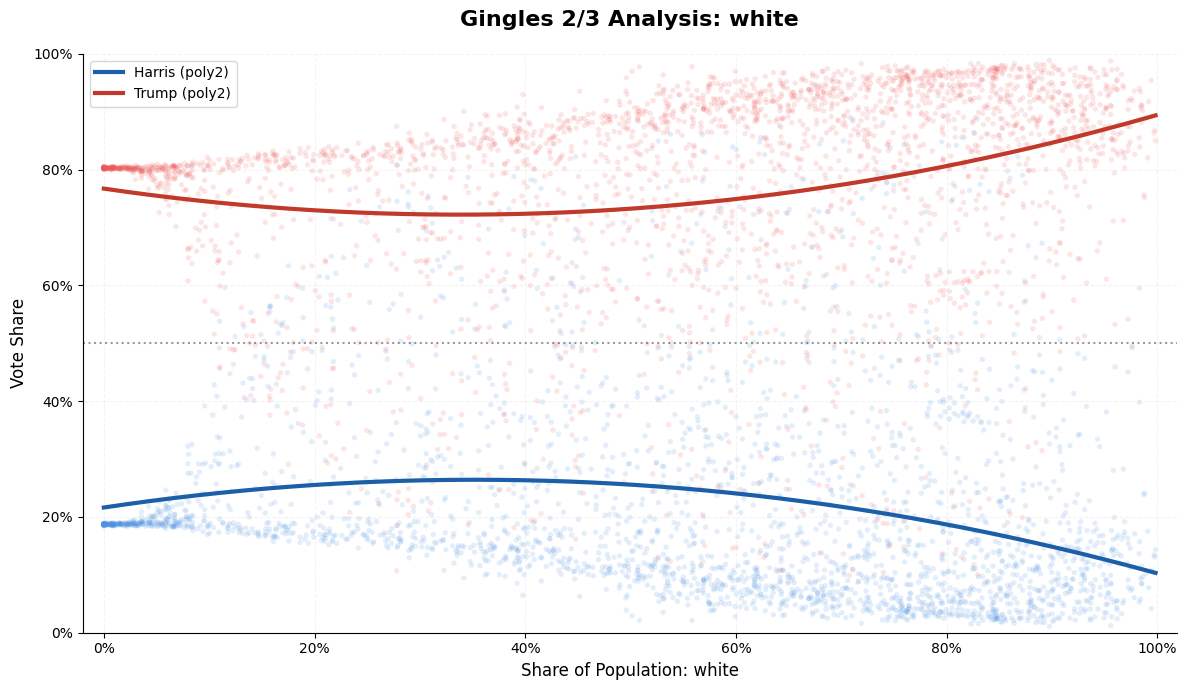

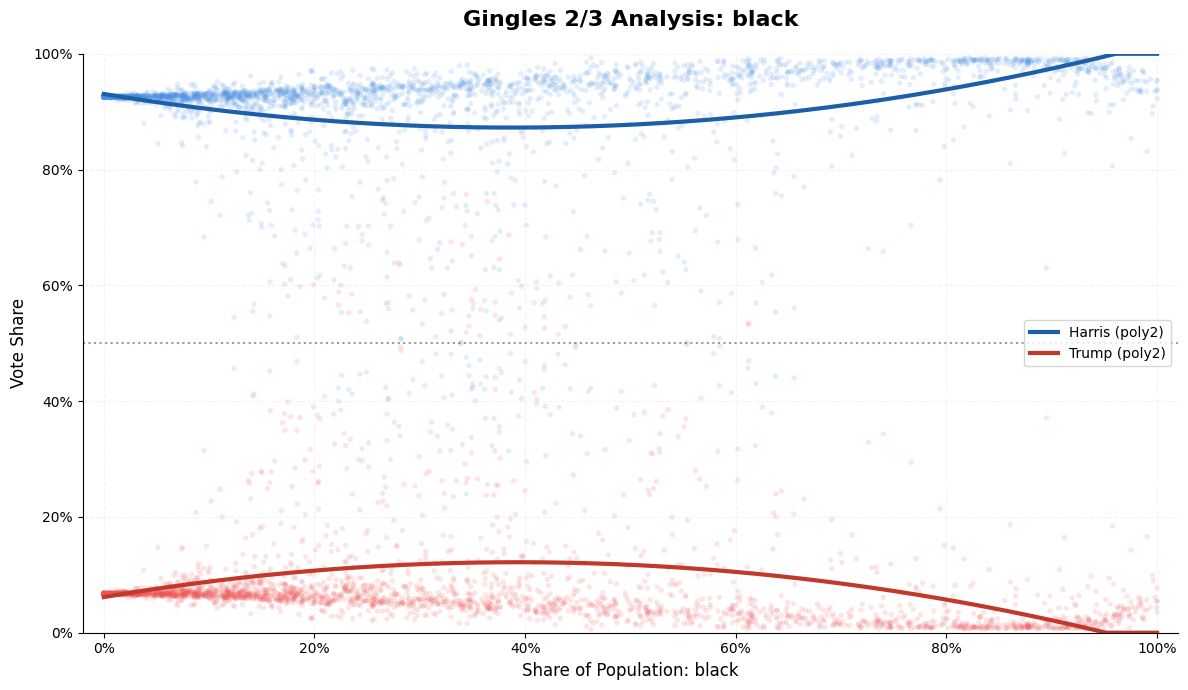

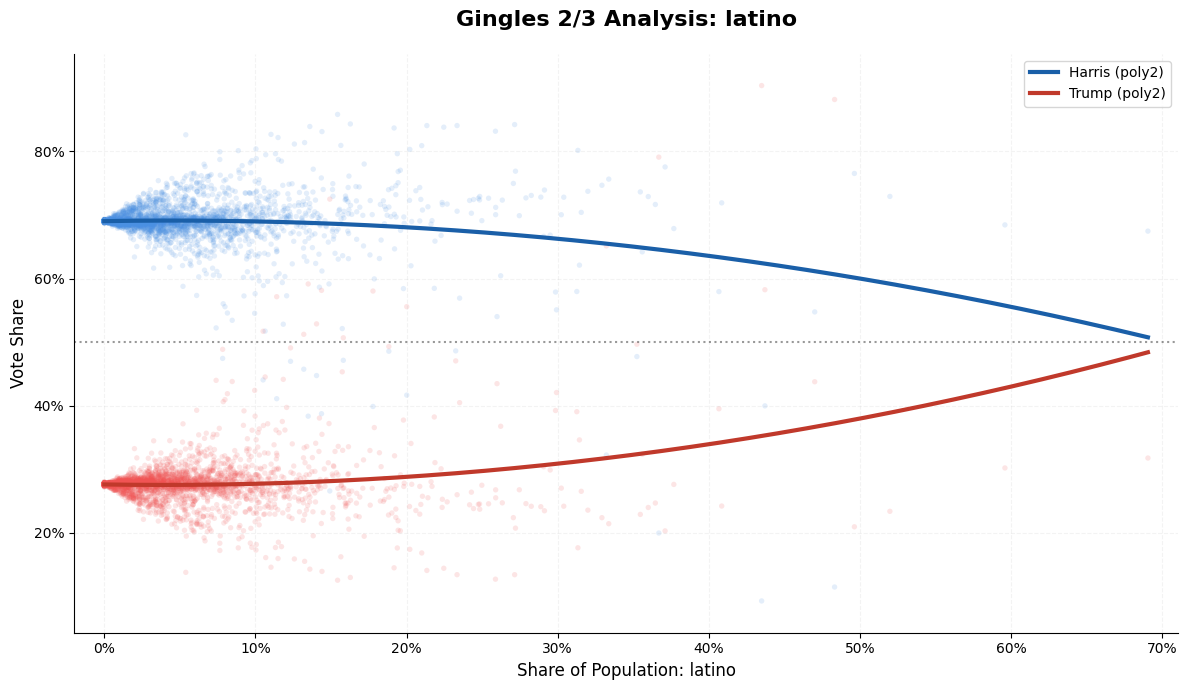

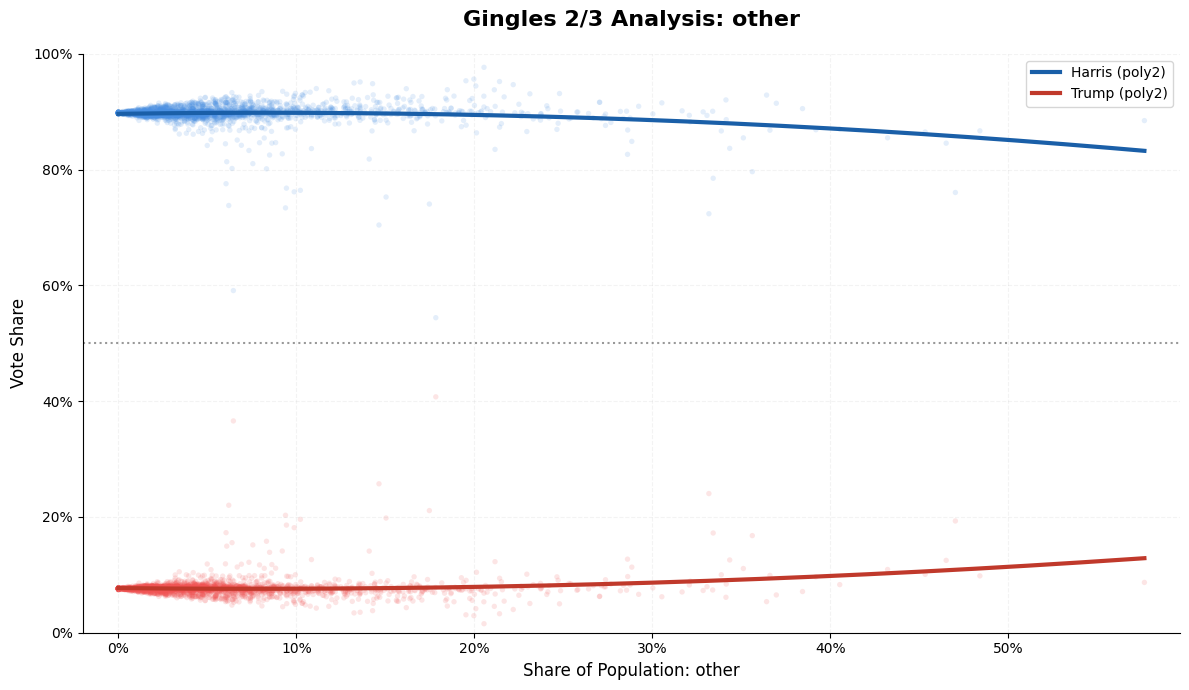

In [19]:
def plot_gingles(result, df, demographic):
    candidateList = result['fits'][demographic]
    harris = next(c for c in candidateList if c['candidate'] == 'harris')
    trump  = next(c for c in candidateList if c['candidate'] == 'trump')

    x  = df[f'{demographic}_pct'].values
    yh = df[f'{demographic}_harris_pct'].values
    yt = df[f'{demographic}_trump_pct'].values
    x_grid = np.linspace(x.min(), x.max(), 500)

    def get_prediction(cand_dict, x_vals):
        name = cand_dict['model']
        p = cand_dict['params']
        
        if name == 'sigmoid':
            y_pred = p['L'] / (1 + np.exp(-(p['b0'] + p['b1'] * x_vals)))
        else:
            fn = MODELS[name][0]
            y_pred = fn(x_vals, *p.values())
            
        return np.clip(y_pred, 0, 1)

    # --- Plotting Code ---
    fig, ax = plt.subplots(figsize=(12, 7), facecolor='white')

    # Scatter points
    ax.scatter(x, yh, color='#4A90E2', s=15, alpha=0.15, edgecolors='none')
    ax.scatter(x, yt, color='#F05454', s=15, alpha=0.15, edgecolors='none')

    # Trend lines
    ax.plot(x_grid, get_prediction(harris, x_grid), color='#1a5fa8', lw=3, label=f"Harris ({harris['model']})")
    ax.plot(x_grid, get_prediction(trump, x_grid), color='#c0392b', lw=3, label=f"Trump ({trump['model']})")

    ax.axhline(0.5, color='black', linestyle=':', alpha=0.4)
    
    ax.set_xlim(x.min() - 0.02, x.max() + 0.02)
    y_all = np.concatenate([yh, yt])
    ax.set_ylim(max(0, y_all.min() - 0.05), min(1, y_all.max() + 0.05))

    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0%}'))
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0%}'))

    ax.set_xlabel(f'Share of Population: {demographic}', fontsize=12)
    ax.set_ylabel('Vote Share', fontsize=12)
    ax.set_title(f'Gingles 2/3 Analysis: {demographic}', fontsize=16, fontweight='bold', pad=20)
    
    ax.legend(frameon=True, loc='best')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(True, linestyle='--', alpha=0.15)

    plt.tight_layout()
    plt.show()

for demographic in demographics:
    plot_gingles(regression, gingles, demographic)

In [20]:
results = {}

for d in demographics:
    x = gingles[f'{d}_pct'].values
    
    results[d] = {}
    for c in candidates:
        y = gingles[f'{d}_{c}_pct'].values
        
        mask = ~np.isnan(x) & ~np.isnan(y)
        corr = np.corrcoef(x[mask], y[mask])[0, 1]
        
        results[d][c] = corr

for d in results:
    print(f"\n{d.upper()}:")
    for c in results[d]:
        print(f"  {c}: {results[d][c]:.4f}")


WHITE:
  harris: -0.1662
  trump: 0.1817

BLACK:
  harris: 0.1255
  trump: -0.1152

LATINO:
  harris: -0.1355
  trump: 0.1589

OTHER:
  harris: -0.1009
  trump: 0.1038


### Save Gingles Data to JSON

In [21]:
def save_to_json(regression, precincts):
    gingles_json = {'state': 'Georgia', 'regression': regression, 'precincts': precincts}

    with open('../output/Georgia/ga_gingles_results.json', 'w') as f:
        json.dump(gingles_json, f, indent=4)

save_to_json(regression, precincts)